In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os
import scipy
import sys

sys.path.append('../Exp6 - iENG vs sENG')
import shared_iENG_sENG
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D


def X_y_from_matfile(path, modality, session):
    X, y = [], []

    if modality=='EMG':
        bluetooth_id = 'E8DD80E550BB'
    elif modality=='ENG':
        bluetooth_id = 'E9AD0E7DCC2B'

    data_per_class_files = os.listdir(path+f'{modality}_{session}/{bluetooth_id}/raw/')

    for cls in data_per_class_files:
        input_path = path+f'{modality}_{session}/{bluetooth_id}/raw/{cls}/'
        files = os.listdir(input_path)

        mat = scipy.io.loadmat(input_path+files[0])
        x_tmp = mat['Data_Fea'].transpose(2, 0, 1)

        X.append(x_tmp.reshape(x_tmp.shape[0], x_tmp.shape[1]*x_tmp.shape[2]))
        y.append(mat['Data_Cls'])

    return X, y

# invasive ENG (Amputee)

In [2]:
path = 'C:/Users/hml76/Desktop/Jupyter/Federated Prototype Learning/Dataset/Ours_cleaned/'
fname = os.listdir(path)

iENG_subjects = {
    "subject2": {"X": [], "Y": []},
    "subject3": {"X": [], "Y": []},
}

for f in fname:
    for i in range(10):
        X = np.array(pd.read_csv(path + f'{f}/rep{i}_X.csv'))
        y = np.array(pd.read_csv(path + f'{f}/rep{i}_Y.csv'))
        #indices = np.random.permutation(len(X)) # shuffle
        #X, y = X[indices], y[indices]

        y_int = np.argmax(y, axis=1)
        num_classes = np.max(y_int) + 1

        if "subject2" in f:
            iENG_subjects["subject2"]["X"].append(X)
            iENG_subjects["subject2"]["Y"].append(y_int)
        elif "subject3" in f:
            iENG_subjects["subject3"]["X"].append(X)
            iENG_subjects["subject3"]["Y"].append(y_int)

In [7]:
y = iENG_subjects["subject2"]['Y'][0]
x = iENG_subjects["subject2"]['X'][0]
x = x.reshape(x.shape[0], 16, 14)[:, [0, 4, 8, 12], :].reshape(x.shape[0], 4*14)   # shape (N, 4, 14)

mask = (y == 0)
iENG_x_zero = x[mask]
iENG_y_zero = y[mask]

iENG_x_zero.shape, iENG_y_zero.shape

((1092, 56), (1092,))

# sENG (HM, BY, MJ)

In [4]:
bluetooth_id = 'E9AD0E7DCC2B'
base_path = 'C:/Users/hml76/PycharmProjects/MindForce/data/sENG_iENG/'
X_sENG_sub1, y_sENG_sub1 = shared_iENG_sENG.return_X_y_get_from_matfile(path = base_path+f'Hunmin/{bluetooth_id}/raw/', num_session=[0], balance=True)
X_sENG_sub2, y_sENG_sub2 = shared_iENG_sENG.return_X_y_get_from_matfile(path = base_path+f'Byeongchan/{bluetooth_id}/raw/', num_session=[0], balance=True)
X_sENG_sub3, y_sENG_sub3 = shared_iENG_sENG.return_X_y_get_from_matfile(path = base_path+f'Minjeong/{bluetooth_id}/raw/', num_session=[0], balance=True)
X_sENG, y_sENG = np.concatenate([X_sENG_sub1, X_sENG_sub2, X_sENG_sub3], axis=0), np.concatenate([y_sENG_sub1, y_sENG_sub2, y_sENG_sub3], axis=0)

y = y_sENG_sub1
x = X_sENG_sub1.reshape(X_sENG_sub1.shape[0], X_sENG_sub1.shape[1]*X_sENG_sub1.shape[2])

mask = (y == 0)
sENG_x_zero = x[mask]
sENG_y_zero = y[mask]

sENG_x_zero.shape, sENG_y_zero.shape

(8626, 4, 14, 1) (8626,)
(8621, 4, 14, 1) (8621,)
(8635, 4, 14, 1) (8635,)


((217, 56), (217,))

# sEMG (HJ, YC, XY)

In [5]:
base_path = 'C:/Users/hml76/PycharmProjects/MindForce/data/EMG_ENG/'
X_sEMG_Sub1, y_sEMG_Sub1 = X_y_from_matfile(path=base_path+f'Hongjun/', modality='EMG', session='v1')
#y_sEMG_Sub1 = X_y_from_matfile(path=base_path+f'{subject}/', modality='ENG', session='v1')
X_sEMG_Sub2, y_sEMG_Sub2 = X_y_from_matfile(path=base_path+f'Youngchul/', modality='EMG', session='v1')
X_sEMG_Sub3, y_sEMG_Sub3 = X_y_from_matfile(path=base_path+f'Xianyu/', modality='EMG', session='v1')

#print(X_sEMG_Sub1.shape, X_sEMG_Sub2.shape, X_sEMG_Sub3.shape)

y = y_sEMG_Sub1[0]
y = y.ravel()        # ensures shape (1724,)
x = X_sEMG_Sub1[0]

mask = (y == 0)
sEMG_x_zero = x[mask]
sEMG_y_zero = y[mask]

sEMG_x_zero.shape, sEMG_y_zero.shape

((798, 56), (798,))

In [8]:
sEMG_x_zero.shape, sENG_x_zero.shape, iENG_x_zero.shape

((798, 56), (217, 56), (1092, 56))

# T-SNE

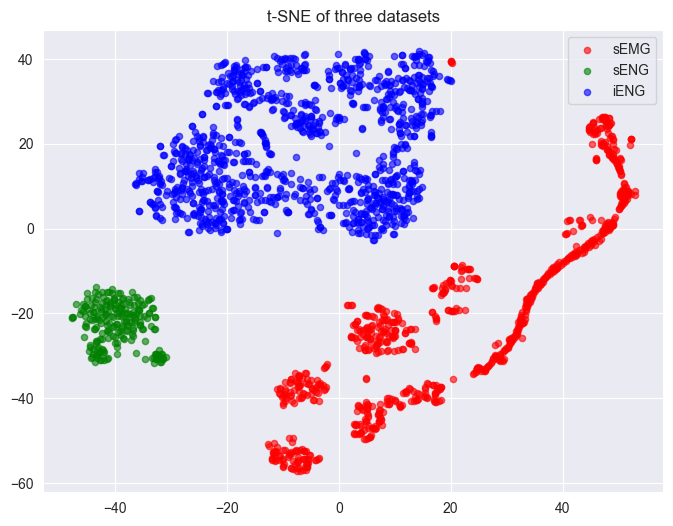

Pairwise distances between prototypes:
 [[ 0.         28.34099888 24.58465137]
 [28.34099888  0.         17.07613614]
 [24.58465137 17.07613614  0.        ]]


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.spatial.distance import cdist

# Suppose your data shapes are (N_i, 4, 14), (N_s1, 4, 14), (N_s2, 4, 14)
# Flatten last two dims for t-SNE
X_i_flat = sEMG_x_zero
X_s1_flat = sENG_x_zero
X_s2_flat = iENG_x_zero

# Stack all for t-SNE
X_all = np.vstack([X_i_flat, X_s1_flat, X_s2_flat])
labels = np.array([0]*X_i_flat.shape[0] + [1]*X_s1_flat.shape[0] + [2]*X_s2_flat.shape[0])

# t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_all)

# Visualize
plt.figure(figsize=(8,6))
colors = ['r', 'g', 'b']
names = ['sEMG', 'sENG', 'iENG']

for i, c, name in zip(range(3), colors, names):
    plt.scatter(X_tsne[labels==i, 0], X_tsne[labels==i, 1], c=c, label=name, alpha=0.6, s=20)

plt.legend()
plt.title("t-SNE of three datasets")
plt.show()

# ------------------------------
# Compute prototypes (mean feature vector)
proto_i = X_i_flat.mean(axis=0)
proto_s1 = X_s1_flat.mean(axis=0)
proto_s2 = X_s2_flat.mean(axis=0)

# Stack prototypes
prototypes = np.vstack([proto_i, proto_s1, proto_s2])

# Compute pairwise distances
dist_matrix = cdist(prototypes, prototypes, metric='euclidean')
print("Pairwise distances between prototypes:\n", dist_matrix)


In [ ]:
['sEMG', 'sENG', 'iENG']



1. feature-dimension
2. gesture-dimension
3.